In [1]:
# from itertools import chain, combinations
from typing import Literal
# from collections import defaultdict, Counter
# from collections.abc import Iterable, Sequence
# import math
import pickle

import matplotlib.pyplot as plt
import numpy as np
# import numpy.typing as npt
# import stim
# from stim import PauliString

import cliffordep
# from cliffordep.type_aliases import ErrorEvent, ErrorLocation, EffectMap, FaultBag
# from cliffordep.pauli_string_tools import forget_sign, FrozenCliffordString
# from cliffordep.probability_tools import parity_probability

# turn figures from blurry png to svg
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

PLOT_STATES = ['S', 'T']
NOISE_STRENGTH = 1e-3

# Getting the Data for Above
The below takes about 1 minute in total to run. If already saved the data in a folder named `data` then skip to next section (Summary).

## Distance-3 Ancilla-1

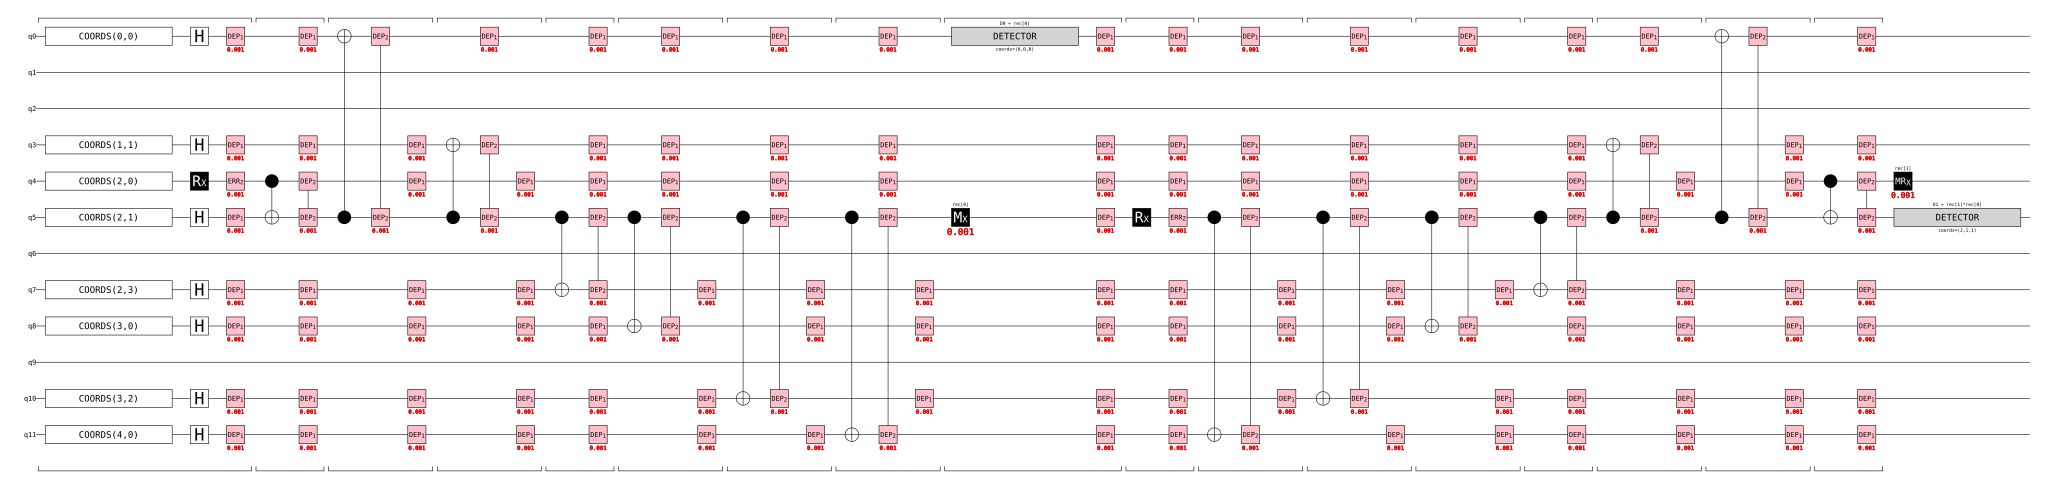

In [2]:
circuit_a1 = cliffordep.circuits.D3DoubleCatCheckA1()
noisy_circuit_a1 = cliffordep.noise.uniformly_depolarize(circuit_a1.INNER_CIRCUIT, noise_level=NOISE_STRENGTH)
# remove last layer of depolarizing noise
noisy_circuit_a1 = noisy_circuit_a1[:-1]
# circuit_a1.INNER_CIRCUIT.diagram('timeline-svg')
noisy_circuit_a1.diagram('timeline-svg')

In [3]:
cultivator_a1 = cliffordep.CultivationCircuit(
    noisy_circuit=noisy_circuit_a1,
    stabilizer_generators=circuit_a1.STABILIZER_GENERATORS,
    logical_x=circuit_a1.LOGICAL_X,
    logical_z=circuit_a1.LOGICAL_Z,
)

In [4]:
fault_combinator_a1 = cliffordep.FaultCombinator(
    circuit=cultivator_a1,
    print_progress=True,
)
fault_combinator_a1.print_basis()

# Finished enumerating all faults. FaultCombinator with 137 faults distributed among 4 syndromes.

Finished enumerating all faults. FaultCombinator with 137 faults distributed among 4 syndromes.
00
  X___________: 0, (0, 15, 2)
  ___X________: 4, (0, 15, 2)
  X__X___XX_XX: 7, (0, 1, 2)
  _______X____: 10, (0, 15, 2)
  ________X___: 13, (0, 15, 2)
  __________X_: 16, (0, 15, 2)
  ___________X: 19, (0, 15, 4)
  X__X_X_XX_XX: 22, (0, 0, 2)
  _____X______: 28, (0, 14, 4)
  ___X___XX_XX: 37, (0, 0, 2)
  _______XX_XX: 48, (0, 0, 2)
  ________X_XX: 59, (0, 0, 2)
  __________XX: 65, (0, 0, 2)
  ____________: 79, (0, 3, 2)
  ___________Y: 82, (0, 6, 1)
  X__X_X_XX_X_: 83, (0, 0, 2)
  ___________Z: 85, (0, 6, 1)
  X__X_X_XX_XZ: 87, (0, 0, 1)
  X__X_X_XX_XY: 90, (0, 0, 1)
  X__X_X_XX_Z_: 91, (0, 0, 1)
  __________Z_: 92, (0, 5, 1)
  X__X_X_XX___: 93, (0, 0, 2)
  __________Y_: 96, (0, 5, 1)
  X__X_X_XX_Y_: 97, (0, 0, 1)
  ________Z___: 101, (0, 4, 1)
  ________Y___: 103, (0, 4, 1)
  X__X_X_X____: 104, (0, 0, 2)
  X__X_X_XY___: 105, (0, 0, 1)
  X__X_X_XZ___: 106, (0, 0, 1)
  X__X_X______: 110, (

In [ ]:
# takes 21.5 s
configurations_a1_o4 = fault_combinator_a1.get_undetected_configurations(
    max_order=4,
    print_progress=True,
)

# Found undetected configurations of length...
#     0, leading to 1 distinct errors.
#     1, leading to 45 distinct errors.
#     2, leading to 817 distinct errors.
#     3, leading to 4389 distinct errors.
#     4, leading to 10592 distinct errors.

Found undetected configurations of length...
    0, leading to 1 distinct errors.
    1, leading to 45 distinct errors.
    2, leading to 817 distinct errors.
    3, leading to 4389 distinct errors.
    4, leading to 10592 distinct errors.


In [ ]:
# takes 5.6 s
states: list[Literal['T', 'S', 'Z']] = ['T', 'S']
kept_strings_a1_o4 = {state: fault_combinator_a1.get_kept_strings(
    configurations_a1_o4,
    cultivated_state=state,
    print_progress=True,
) for state in states}

# T state cultivation: for order...
#     0, 1 (0) errors are kept and lead to identity (error).
#     1, 2 (0) errors are kept and lead to identity (error).
#     2, 17 (12) errors are kept and lead to identity (error).
#     3, 106 (118) errors are kept and lead to identity (error).
#     4, 290 (278) errors are kept and lead to identity (error).
# S state cultivation: for order...
#     0, 1 (0) errors are kept and lead to identity (error).
#     1, 2 (0) errors are kept and lead to identity (error).
#     2, 7 (0) errors are kept and lead to identity (error).
#     3, 16 (40) errors are kept and lead to identity (error).
#     4, 84 (104) errors are kept and lead to identity (error).

T state cultivation: for order...
    0, 1 (0) errors are kept and lead to identity (error).
    1, 2 (0) errors are kept and lead to identity (error).
    2, 17 (12) errors are kept and lead to identity (error).
    3, 106 (118) errors are kept and lead to identity (error).
    4, 290 (278) errors are kept and lead to identity (error).
S state cultivation: for order...
    0, 1 (0) errors are kept and lead to identity (error).
    1, 2 (0) errors are kept and lead to identity (error).
    2, 7 (0) errors are kept and lead to identity (error).
    3, 16 (40) errors are kept and lead to identity (error).
    4, 84 (104) errors are kept and lead to identity (error).


Can use below cell to save the data you've just generated.

In [ ]:
# with open('data/fault_combinator_a1.pkl', 'wb') as f:
#     pickle.dump(fault_combinator_a1, f)
# with open('data/configurations_a1_o4.pkl', 'wb') as f:
#     pickle.dump(configurations_a1_o4, f)
# with open('data/kept_strings_a1_o4.pkl', 'wb') as f:
#     pickle.dump(kept_strings_a1_o4, f)

# with open('data/fault_combinator_a1.pkl', 'rb') as f:
#     fault_combinator_a1 = pickle.load(f)
# with open('data/configurations_a1_o4.pkl', 'rb') as f:
#     configurations_a1_o4 = pickle.load(f)
# with open('data/kept_strings_a1_o4.pkl', 'rb') as f:
#     kept_strings_a1_o4 = pickle.load(f)

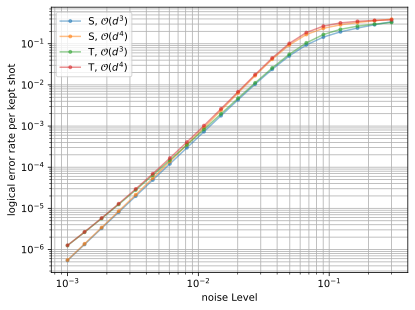

In [8]:
noise_levels = np.geomspace(1e-3, 3e-1, 20)
fig, ax = plt.subplots(1, 1)
for state in PLOT_STATES:
    for max_order in (3, 4):
        y = [fault_combinator_a1.error_rate_per_kept_shot(
            kept_strings_a1_o4[state][:max_order+1],
            noise_level=noise_level)
            for noise_level in noise_levels]
        plt.plot(noise_levels, y, marker='.', label=fr'{state}, $\mathcal{{O}}(d^{max_order})$', alpha=0.5)
plt.loglog()
plt.xlabel('noise Level')
plt.ylabel('logical error rate per kept shot')
plt.grid(True, which='both')
plt.legend()
plt.show()

## Distance-3 Ancilla-6

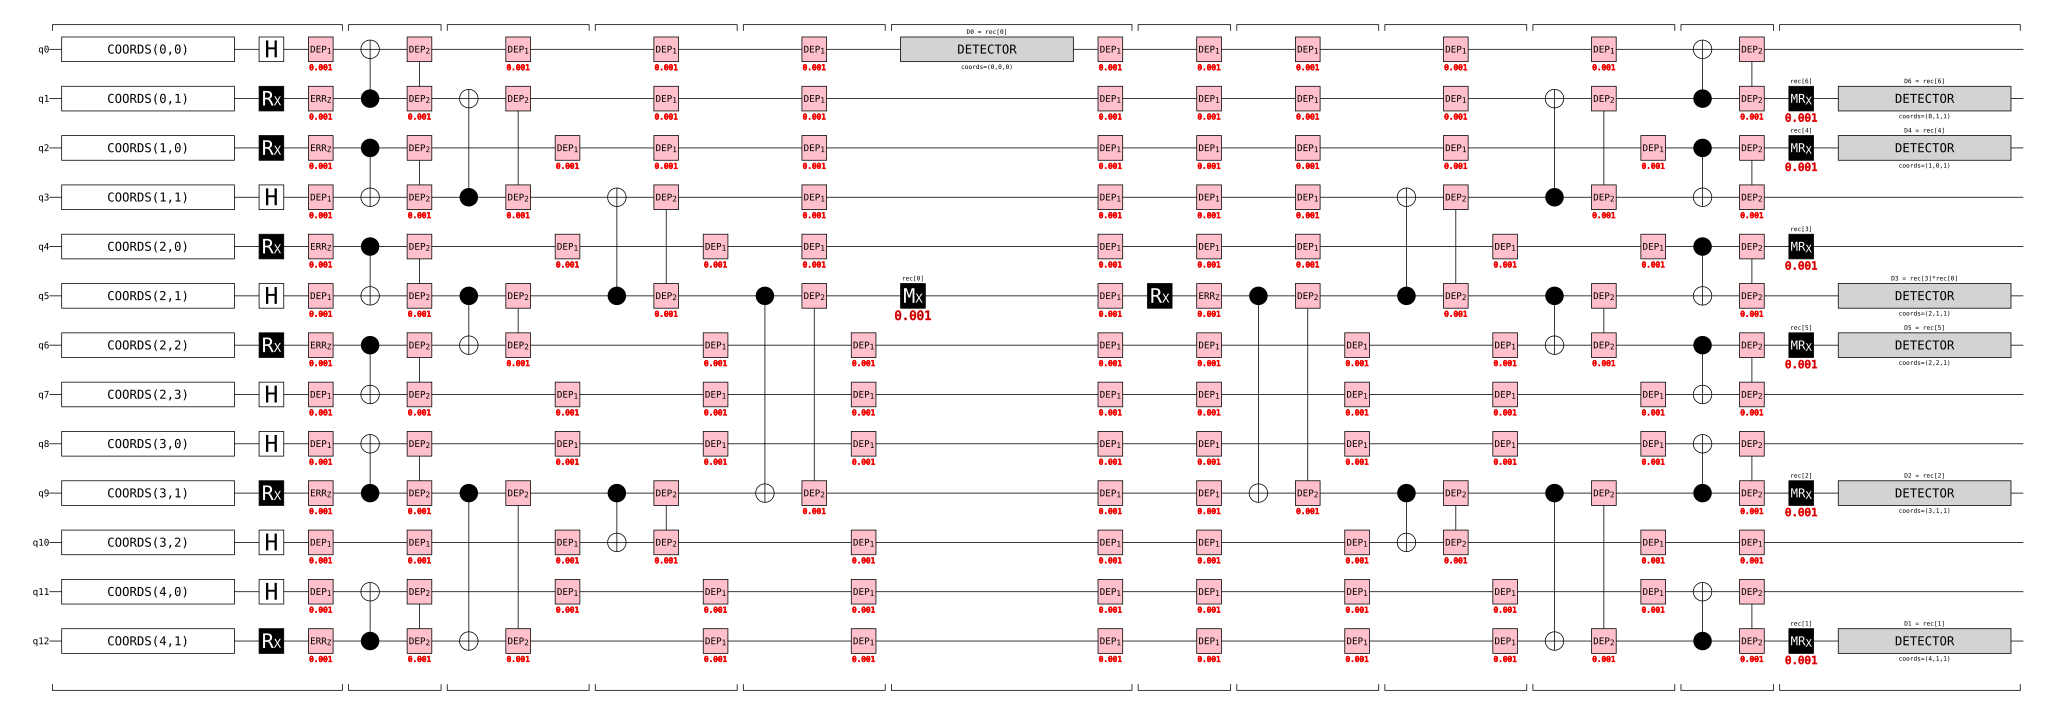

In [9]:
circuit_a6 = cliffordep.circuits.D3DoubleCatCheckA6()
noisy_circuit_a6 = cliffordep.noise.uniformly_depolarize(circuit_a6.INNER_CIRCUIT, noise_level=NOISE_STRENGTH)
# remove last layer of depolarizing noise
noisy_circuit_a6 = noisy_circuit_a6[:-1]
# circuit_a6.INNER_CIRCUIT.diagram('timeline-svg')
noisy_circuit_a6.diagram('timeline-svg')

In [10]:
cultivator_a6 = cliffordep.CultivationCircuit(
    noisy_circuit=noisy_circuit_a6,
    stabilizer_generators=circuit_a6.STABILIZER_GENERATORS,
    logical_x=circuit_a6.LOGICAL_X,
    logical_z=circuit_a6.LOGICAL_Z,
)

In [11]:
fault_combinator_a6 = cliffordep.FaultCombinator(
    circuit=cultivator_a6,
    print_progress=True,
)
fault_combinator_a6.print_basis()

# Finished enumerating all faults. FaultCombinator with 158 faults distributed among 19 syndromes.

Finished enumerating all faults. FaultCombinator with 158 faults distributed among 19 syndromes.
0000000
  X____________: 0, (0, 15, 6)
  ___X_________: 4, (0, 9, 6)
  X__X___XX_XX_: 7, (0, 1, 2)
  _______X_____: 10, (0, 15, 6)
  ________X____: 13, (0, 9, 6)
  __________X__: 16, (0, 9, 2)
  ___________X_: 19, (0, 15, 6)
  _____________: 30, (0, 3, 12)
  X__X_X_XX_XX_: 37, (0, 0, 2)
  _____X_______: 43, (0, 8, 4)
  X__X_________: 61, (0, 4, 4)
  X__X____X_XX_: 67, (0, 0, 2)
  ________X__X_: 72, (0, 0, 4)
  ________X_XX_: 87, (0, 2, 6)
  X__X_X_X_____: 109, (0, 0, 2)
  _____X_X_____: 115, (0, 0, 2)
  __________Z__: 120, (0, 2, 1)
  ________X_YX_: 121, (0, 0, 1)
  ________X_ZX_: 123, (0, 0, 1)
  __________Y__: 125, (0, 2, 1)
  Y____________: 146, (0, 0, 2)
  Z____________: 147, (0, 0, 2)
  ________Y____: 148, (0, 0, 2)
  ________Z____: 149, (0, 0, 2)
  _______Y_____: 150, (0, 0, 2)
  _______Z_____: 151, (0, 0, 2)
  ___________Y_: 152, (0, 0, 2)
  ___________Z_: 153, (0, 0, 2)
  _____Z____

In [12]:
# takes 6.8 s
configurations_a6_o4 = fault_combinator_a6.get_undetected_configurations(
    max_order=4,
    print_progress=True,
)

# Found undetected configurations of length...
#     0, leading to 1 distinct errors.
#     1, leading to 32 distinct errors.
#     2, leading to 413 distinct errors.
#     3, leading to 2544 distinct errors.
#     4, leading to 8048 distinct errors.

Found undetected configurations of length...
    0, leading to 1 distinct errors.
    1, leading to 32 distinct errors.
    2, leading to 413 distinct errors.
    3, leading to 2544 distinct errors.
    4, leading to 8048 distinct errors.


In [13]:
# takes 4.2 s
states: list[Literal['T', 'S', 'Z']] = ['T', 'S']
kept_strings_a6_o4 = {state: fault_combinator_a6.get_kept_strings(
    configurations_a6_o4,
    cultivated_state=state,
    print_progress=True,
) for state in states}

# T state cultivation: for order...
#     0, 1 (0) errors are kept and lead to identity (error).
#     1, 2 (0) errors are kept and lead to identity (error).
#     2, 8 (4) errors are kept and lead to identity (error).
#     3, 68 (65) errors are kept and lead to identity (error).
#     4, 184 (180) errors are kept and lead to identity (error).
# S state cultivation: for order...
#     0, 1 (0) errors are kept and lead to identity (error).
#     1, 2 (0) errors are kept and lead to identity (error).
#     2, 6 (0) errors are kept and lead to identity (error).
#     3, 16 (24) errors are kept and lead to identity (error).
#     4, 46 (64) errors are kept and lead to identity (error).

T state cultivation: for order...
    0, 1 (0) errors are kept and lead to identity (error).
    1, 2 (0) errors are kept and lead to identity (error).
    2, 8 (4) errors are kept and lead to identity (error).
    3, 68 (65) errors are kept and lead to identity (error).
    4, 184 (180) errors are kept and lead to identity (error).
S state cultivation: for order...
    0, 1 (0) errors are kept and lead to identity (error).
    1, 2 (0) errors are kept and lead to identity (error).
    2, 6 (0) errors are kept and lead to identity (error).
    3, 16 (24) errors are kept and lead to identity (error).
    4, 46 (64) errors are kept and lead to identity (error).


In [ ]:
# with open('data/fault_combinator_a6.pkl', 'wb') as f:
#     pickle.dump(fault_combinator_a6, f)
# with open('data/configurations_a6_o4.pkl', 'wb') as f:
#     pickle.dump(configurations_a6_o4, f)
# with open('data/kept_strings_a6_o4.pkl', 'wb') as f:
#     pickle.dump(kept_strings_a6_o4, f)

# with open('data/fault_combinator_a6.pkl', 'rb') as f:
#     fault_combinator_a6 = pickle.load(f)
# with open('data/configurations_a6_o4.pkl', 'rb') as f:
#     configurations_a6_o4 = pickle.load(f)
# with open('data/kept_strings_a6_o4.pkl', 'rb') as f:
#     kept_strings_a6_o4 = pickle.load(f)

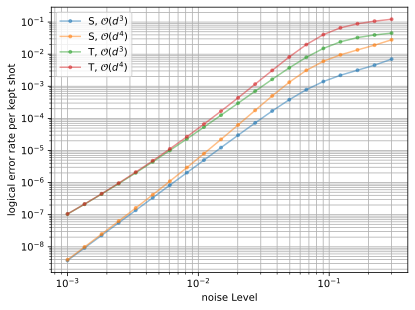

In [14]:
noise_levels = np.geomspace(1e-3, 3e-1, 20)
fig, ax = plt.subplots(1, 1)
for state in PLOT_STATES:
    for max_order in (3, 4):
        y = [fault_combinator_a6.error_rate_per_kept_shot(
            kept_strings_a6_o4[state][:max_order+1],
            noise_level=noise_level)
            for noise_level in noise_levels]
        plt.plot(noise_levels, y, marker='.', label=fr'{state}, $\mathcal{{O}}(d^{max_order})$', alpha=0.5)
plt.loglog()
plt.xlabel('noise Level')
plt.ylabel('logical error rate per kept shot')
plt.grid(True, which='both')
plt.legend()
plt.show()

## Distance-3 Ancilla-7

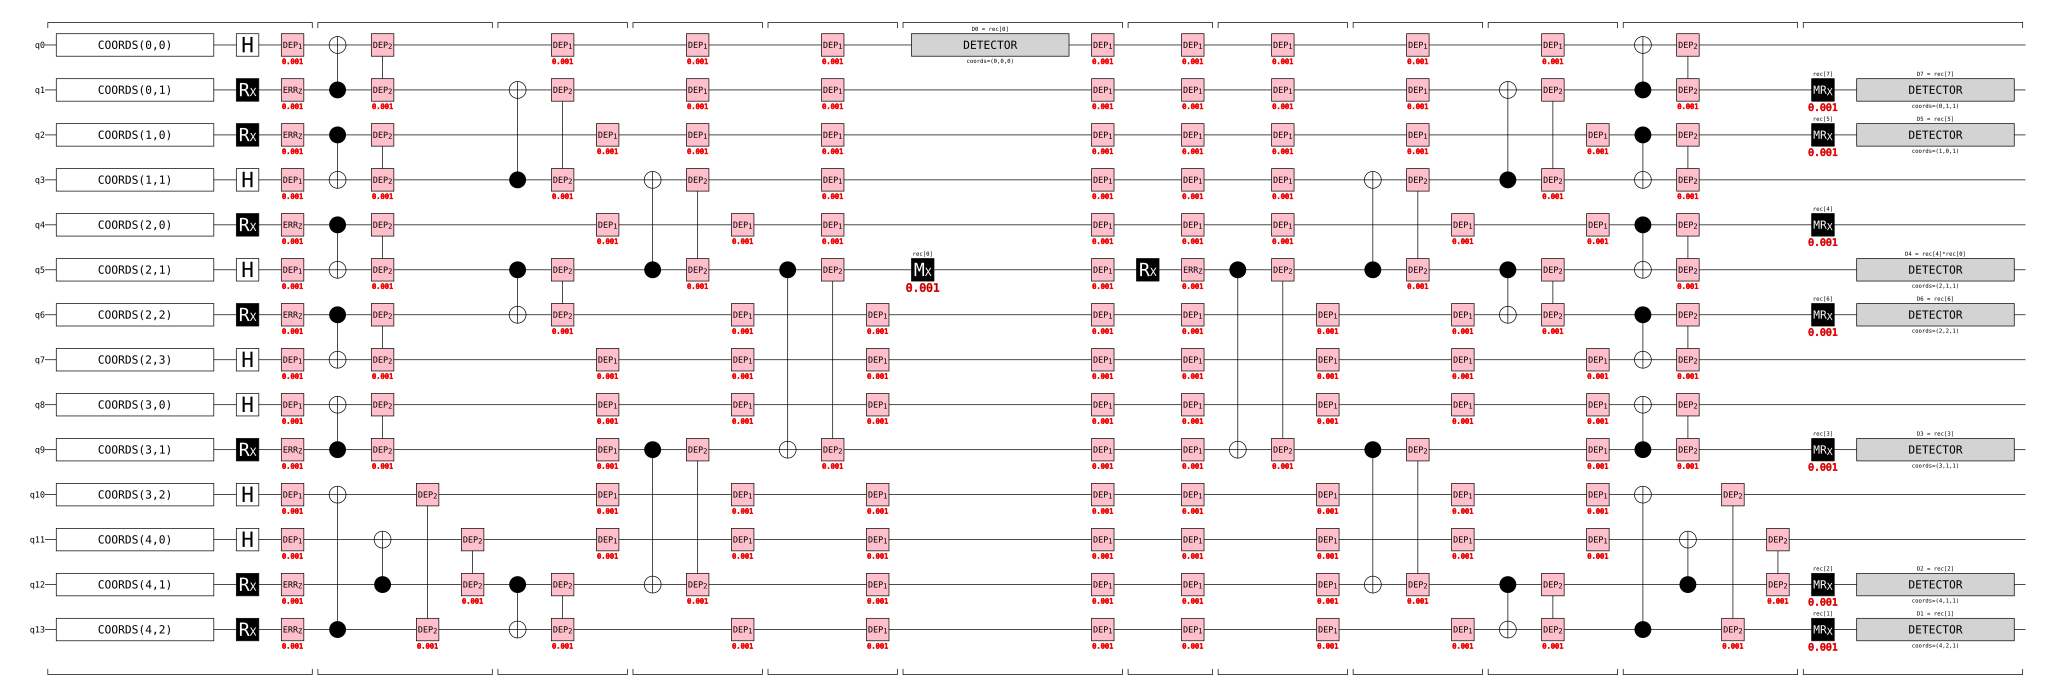

In [15]:
circuit_a7 = cliffordep.circuits.D3DoubleCatCheckA7()
noisy_circuit_a7 = cliffordep.noise.uniformly_depolarize(circuit_a7.INNER_CIRCUIT, NOISE_STRENGTH)
# remove last layer of depolarizing noise
noisy_circuit_a7 = noisy_circuit_a7[:-1]
# circuit_a7.INNER_CIRCUIT.diagram('timeline-svg')
noisy_circuit_a7.diagram('timeline-svg')

In [16]:
cultivator_a7 = cliffordep.CultivationCircuit(
    noisy_circuit=noisy_circuit_a7,
    stabilizer_generators=circuit_a7.STABILIZER_GENERATORS,
    logical_x=circuit_a7.LOGICAL_X,
    logical_z=circuit_a7.LOGICAL_Z,
)
fault_combinator_a7 = cliffordep.FaultCombinator(
    circuit=cultivator_a7,
    print_progress=True,
)
fault_combinator_a7.print_basis()

# Finished enumerating all faults. FaultCombinator with 164 faults distributed among 22 syndromes.

Finished enumerating all faults. FaultCombinator with 164 faults distributed among 22 syndromes.
00000000
  X_____________: 0, (0, 15, 6)
  ___X__________: 4, (0, 9, 6)
  X__X___XX_XX__: 7, (0, 1, 2)
  _______X______: 10, (0, 15, 6)
  ________X_____: 13, (0, 11, 6)
  __________X___: 16, (0, 15, 6)
  ___________X__: 19, (0, 9, 6)
  ______________: 31, (0, 3, 14)
  X__X_X_XX_XX__: 38, (0, 0, 2)
  _____X________: 44, (0, 8, 4)
  X__X__________: 65, (0, 4, 4)
  X__X____X_XX__: 71, (0, 0, 2)
  __________XX__: 78, (0, 4, 4)
  ________X_XX__: 91, (0, 2, 6)
  X__X_X_X______: 113, (0, 0, 2)
  _____X_X______: 119, (0, 0, 2)
  Y_____________: 150, (0, 0, 2)
  Z_____________: 151, (0, 0, 2)
  ________Y_____: 152, (0, 0, 2)
  ________Z_____: 153, (0, 0, 2)
  _______Y______: 154, (0, 0, 2)
  _______Z______: 155, (0, 0, 2)
  _____Z________: 156, (0, 0, 2)
  _____Y________: 157, (0, 0, 2)
  ___Z__________: 158, (0, 0, 2)
  ___Y__________: 159, (0, 0, 2)
  __________Y___: 160, (0, 0, 2)
  __________Z__

In [17]:
# takes 8.2 s
configurations_a7_o4 = fault_combinator_a7.get_undetected_configurations(
    max_order=4,
    print_progress=True,
)

# Found undetected configurations of length...
#     0, leading to 1 distinct errors.
#     1, leading to 30 distinct errors.
#     2, leading to 373 distinct errors.
#     3, leading to 2280 distinct errors.
#     4, leading to 7368 distinct errors.

Found undetected configurations of length...
    0, leading to 1 distinct errors.
    1, leading to 30 distinct errors.
    2, leading to 373 distinct errors.
    3, leading to 2280 distinct errors.
    4, leading to 7368 distinct errors.


In [18]:
# takes 4.3 s
kept_strings_a7_o4 = {state: fault_combinator_a7.get_kept_strings(
    configurations_a7_o4,
    cultivated_state=state,
    print_progress=True,
) for state in states}

# T state cultivation: for order...
#     0, 1 (0) errors are kept and lead to identity (error).
#     1, 2 (0) errors are kept and lead to identity (error).
#     2, 6 (4) errors are kept and lead to identity (error).
#     3, 60 (54) errors are kept and lead to identity (error).
#     4, 154 (148) errors are kept and lead to identity (error).
# S state cultivation: for order...
#     0, 1 (0) errors are kept and lead to identity (error).
#     1, 2 (0) errors are kept and lead to identity (error).
#     2, 6 (0) errors are kept and lead to identity (error).
#     3, 16 (20) errors are kept and lead to identity (error).
#     4, 38 (52) errors are kept and lead to identity (error).

T state cultivation: for order...
    0, 1 (0) errors are kept and lead to identity (error).
    1, 2 (0) errors are kept and lead to identity (error).
    2, 6 (4) errors are kept and lead to identity (error).
    3, 60 (54) errors are kept and lead to identity (error).
    4, 154 (148) errors are kept and lead to identity (error).
S state cultivation: for order...
    0, 1 (0) errors are kept and lead to identity (error).
    1, 2 (0) errors are kept and lead to identity (error).
    2, 6 (0) errors are kept and lead to identity (error).
    3, 16 (20) errors are kept and lead to identity (error).
    4, 38 (52) errors are kept and lead to identity (error).


In [ ]:
# with open('data/fault_combinator_a7.pkl', 'wb') as f:
#     pickle.dump(fault_combinator_a7, f)
# with open('data/configurations_a7_o4.pkl', 'wb') as f:
#     pickle.dump(configurations_a7_o4, f)
# with open('data/kept_strings_a7_o4.pkl', 'wb') as f:
#     pickle.dump(kept_strings_a7_o4, f)

# with open('data/fault_combinator_a7.pkl', 'rb') as f:
#     fault_combinator_a7 = pickle.load(f)
# with open('data/configurations_a7_o4.pkl', 'rb') as f:
#     configurations_a7_o4 = pickle.load(f)
# with open('data/kept_strings_a7_o4.pkl', 'rb') as f:
#     kept_strings_a7_o4 = pickle.load(f)

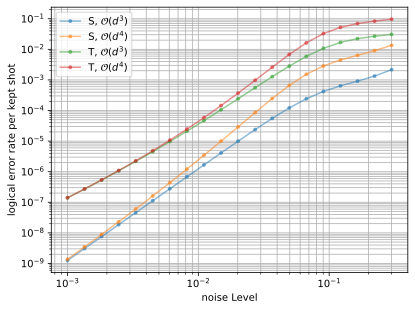

In [19]:
noise_levels = np.geomspace(1e-3, 3e-1, 20)
fig, ax = plt.subplots(1, 1)
for state in PLOT_STATES:
    for max_order in (3, 4):
        y = [fault_combinator_a7.error_rate_per_kept_shot(
            kept_strings_a7_o4[state][:max_order+1],
            noise_level=noise_level)
            for noise_level in noise_levels]
        plt.plot(noise_levels, y, marker='.', label=fr'{state}, $\mathcal{{O}}(d^{max_order})$', alpha=0.5)
plt.loglog()
plt.xlabel('noise Level')
plt.ylabel('logical error rate per kept shot')
plt.grid(True, which='both')
plt.legend()
plt.show()

# Summary

In [24]:
with open('data/fault_combinator_a1.pkl', 'rb') as f:
    fault_combinator_a1 = pickle.load(f)
with open('data/kept_strings_a1_o4.pkl', 'rb') as f:
    kept_strings_a1_o4 = pickle.load(f)

with open('data/fault_combinator_a6.pkl', 'rb') as f:
    fault_combinator_a6 = pickle.load(f)
with open('data/kept_strings_a6_o4.pkl', 'rb') as f:
    kept_strings_a6_o4 = pickle.load(f)

with open('data/fault_combinator_a7.pkl', 'rb') as f:
    fault_combinator_a7 = pickle.load(f)
with open('data/kept_strings_a7_o4.pkl', 'rb') as f:
    kept_strings_a7_o4 = pickle.load(f)

Text(0, 0.5, 'logical error rate per kept shot')

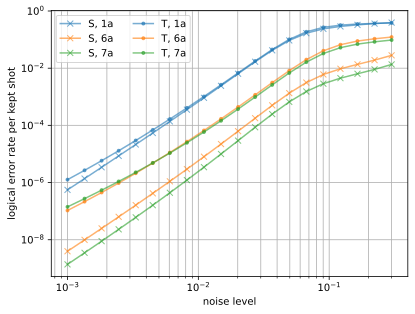

In [25]:
noise_levels = np.geomspace(1e-3, 3e-1, 20)
color_map = {1: 'tab:blue', 6: 'tab:orange', 7: 'tab:green'}
marker_map = {'T': '.', 'S': 'x'}
# figure = plt.figure(figsize=(5, 5))
for state in PLOT_STATES:
    for ancilla_count, kept_strings, emc in (
        (1, kept_strings_a1_o4, fault_combinator_a1),
        (6, kept_strings_a6_o4, fault_combinator_a6),
        (7, kept_strings_a7_o4, fault_combinator_a7),
    ):
        y = [emc.error_rate_per_kept_shot(kept_strings[state], noise_level=noise_level)
            for noise_level in noise_levels]
        plt.plot(
            noise_levels,
            y,
            marker=marker_map[state],
            label=fr'{state}, {ancilla_count}a',
            color=color_map[ancilla_count],
            alpha=0.6,
        )
    plt.loglog()
    plt.grid(True, which='both')
    plt.legend(
        ncols=2,
    )
plt.xlabel('noise level')
plt.ylabel('logical error rate per kept shot')
# plt.savefig(
#     'plots/ancilla_1_vs_6_vs_7.pdf',
#     bbox_inches='tight',
#     pad_inches=0.1,
# )